# Notebook 07: Calibration, ranking and SHAP

**Objective:** Check whether the selected LightGBM model's probabilities need calibration, recompute ranking tables after the chosen calibration, and explain the model with SHAP. Train on dev (2019 to 2021), calibrate and score on val (2022). Holdout rows are never loaded.

**Design, fixed before any result here.**
- Model: LightGBM for both targets, refit on dev with the tree counts chosen in Notebook 04 (291 for adverse_outcome, 51 for readmission_30d).
- Calibrators: none, Platt scaling (logistic regression on the logit of the score) and isotonic regression.
- A calibrator fitted on val and scored on the same rows would look better than it is. Val is therefore split by arrival time at the median arrival_ts. Calibrators are fitted on the first half and scored on the second half.
- Selection rule: pick the calibrator with the lowest Brier score on the second half. If it improves on "none" by less than 0.0005 Brier, keep "none".
- Platt scaling is monotone, so it cannot change PR-AUC or Recall@K. Isotonic regression can create tied scores, so ranking metrics are recomputed with a random tie-break.
- The tree counts were chosen by early stopping on val, so val scores are slightly optimistic.
- For the final holdout (Notebook 09), the chosen calibrator is refitted on all of val and applied to holdout once.
- Ranking output is analytical prioritisation of a synthetic benchmark, not clinical decision support. SHAP values describe model behaviour, not causes.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

warnings.filterwarnings("ignore")
targets = ["adverse_outcome", "readmission_30d"]

# ---- data: holdout rows are filtered out at read time ----
mr = pd.read_parquet("../data/interim/model_ready.parquet", filters=[("split", "!=", "holdout")])
feat_tbl = pd.read_csv("../reports/tables/feature_summary.csv")
features = feat_tbl["feature"].tolist()
cat_features = feat_tbl.loc[feat_tbl["kind"] == "categorical", "feature"].tolist()
assert not {"arrival_day", "arrival_month", "arrival_day_of_week", "arrival_year"} & set(features)

dev = mr[mr["split"] == "dev"].reset_index(drop=True)
val = mr[mr["split"] == "val"].reset_index(drop=True)
del mr

# =============== SHARED FUNCTIONS (copied from Notebooks 04 and 05) ===============
def to_cat(d):
    X = d[features].copy()
    for c in cat_features:
        X[c] = X[c].astype(pd.CategoricalDtype(sorted(dev[c].unique())))
    return X

def ece_score(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    return sum((bins == b).mean() * abs(p[bins == b].mean() - y[bins == b].mean())
               for b in range(n_bins) if (bins == b).any())

def paired_boot(y, p_a, p_b, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p_a, p_b = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    diffs = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        diffs.append(average_precision_score(y[i], p_b[i]) - average_precision_score(y[i], p_a[i]))
    return np.percentile(diffs, [2.5, 50, 97.5]).round(4)

K_BY_TARGET = {"adverse_outcome": [0.05, 0.10, 0.20, 0.30, 0.40],
               "readmission_30d": [0.01, 0.05, 0.10, 0.20]}

def rank_table(y, score, ks, seed=42):
    y, score = np.asarray(y), np.asarray(score)
    jitter = np.random.default_rng(seed).random(len(score)) * 1e-9
    order = np.argsort(-(score + jitter))
    total, prev, rows = int(y.sum()), y.mean(), []
    for k in ks:
        n = int(round(len(y) * k))
        hits = int(y[order[:n]].sum())
        rows.append({"K": k, "n_review": n, "events_captured": hits, "total_events": total,
                     "recall": hits / total, "precision": hits / n,
                     "lift": (hits / n) / prev, "false_positives": n - hits})
    return pd.DataFrame(rows)
# ==================================================================================

# ---- refit LightGBM on dev with the fixed tree counts ----
Xdev, Xval = to_cat(dev), to_cat(val)
TREES = {"adverse_outcome": 291, "readmission_30d": 51}
vp = pd.read_parquet("../data/interim/val_predictions_classical.parquet")
assert (vp["encounter_id"].values == val["encounter_id"].values).all(), "row order differs"

models, p_val = {}, {}
for t in targets:
    t0 = time.time()
    m = lgb.LGBMClassifier(n_estimators=TREES[t], learning_rate=0.05, num_leaves=31,
                           min_child_samples=20, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, n_jobs=-1, random_state=42, verbose=-1)
    m.fit(Xdev, dev[t])
    models[t], p_val[t] = m, m.predict_proba(Xval)[:, 1]
    saved = vp[f"lightgbm_{t}"].values
    print(t, "| refit val PR-AUC:", round(average_precision_score(val[t], p_val[t]), 4),
          "| saved:", round(average_precision_score(val[t], saved), 4),
          "| max abs diff in predictions:", float(np.abs(p_val[t] - saved).max()),
          "| seconds:", round(time.time() - t0))

# ---- chronological split of val for calibration ----
cut = val["arrival_ts"].median()
fit_mask = (val["arrival_ts"] < cut).values
print()
print("calibration-fit half :", int(fit_mask.sum()), "rows,", val.loc[fit_mask, "arrival_ts"].min(),
      "to", val.loc[fit_mask, "arrival_ts"].max())
print("calibration-eval half:", int((~fit_mask).sum()), "rows,", val.loc[~fit_mask, "arrival_ts"].min(),
      "to", val.loc[~fit_mask, "arrival_ts"].max())
print(pd.DataFrame({"fit half": val.loc[fit_mask, targets].mean(),
                    "eval half": val.loc[~fit_mask, targets].mean()}).round(4))
print("splits present:", sorted(set(dev["split"]) | set(val["split"])))

# ---- is SHAP installed? ----
try:
    import shap
    print("shap", shap.__version__)
except Exception as e:
    print("shap not available:", type(e).__name__, str(e)[:150])

adverse_outcome | refit val PR-AUC: 0.7553 | saved: 0.7553 | max abs diff in predictions: 0.0 | seconds: 6
readmission_30d | refit val PR-AUC: 0.2138 | saved: 0.2138 | max abs diff in predictions: 0.0 | seconds: 2

calibration-fit half : 66919 rows, 2022-01-01 00:00:00 to 2022-07-02 17:00:00
calibration-eval half: 66934 rows, 2022-07-02 18:00:00 to 2022-12-31 23:00:00
                 fit half  eval half
adverse_outcome    0.4082     0.4079
readmission_30d    0.1375     0.1346
splits present: ['dev', 'val']
shap not available: ModuleNotFoundError No module named 'shap'


         target   method  pr_auc  roc_auc   brier  brier_diff_vs_none  diff_ci_low  diff_ci_high     ece  n_unique_scores  chosen
adverse_outcome     none 0.75629  0.80452 0.17371             0.00000      0.00000       0.00000 0.00550            66934    True
adverse_outcome    platt 0.75629  0.80452 0.17372             0.00000     -0.00000       0.00001 0.00540            66934   False
adverse_outcome isotonic 0.75063  0.80439 0.17372             0.00001     -0.00006       0.00006 0.00293              205   False
readmission_30d     none 0.21007  0.60409 0.11366             0.00000      0.00000       0.00000 0.00606            64916    True
readmission_30d    platt 0.21007  0.60409 0.11365            -0.00002     -0.00007       0.00004 0.00366            64916   False
readmission_30d isotonic 0.20435  0.60345 0.11368             0.00002     -0.00006       0.00008 0.00385               83   False

chosen calibrator: {'adverse_outcome': 'none', 'readmission_30d': 'none'}


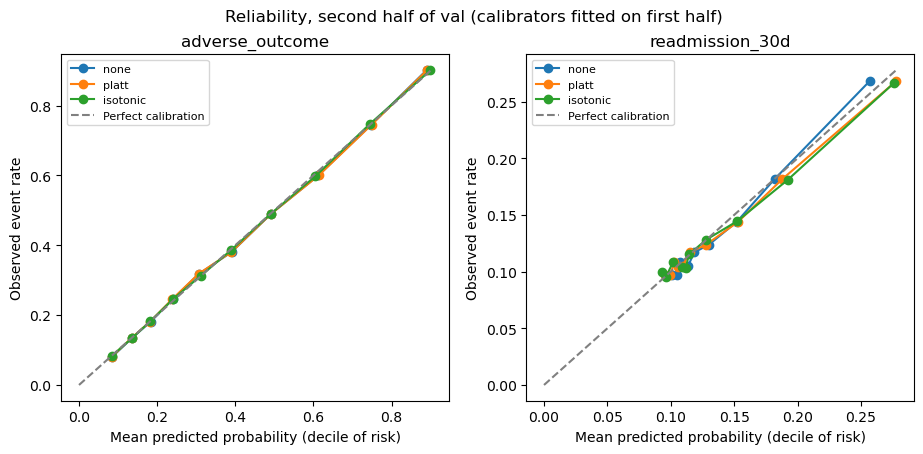

tables/calibration_metrics.csv | KB: 0.6
figures/calibration_curve.png | KB: 105.0


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt

tables = Path("../reports/tables"); tables.mkdir(parents=True, exist_ok=True)
figs = Path("../reports/figures"); figs.mkdir(parents=True, exist_ok=True)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_calibrators(s_fit, y_fit):
    platt = LogisticRegression(C=1e6, max_iter=1000).fit(logit(s_fit).reshape(-1, 1), y_fit)
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(s_fit, y_fit)
    return {"none": lambda s: s,
            "platt": lambda s: platt.predict_proba(logit(s).reshape(-1, 1))[:, 1],
            "isotonic": lambda s: iso.predict(s)}

def brier_diff_ci(y, p_a, p_b, n=200, seed=0):
    """Paired bootstrap of Brier(b) - Brier(a). Negative means b is better."""
    rs = np.random.default_rng(seed)
    d = (p_b - y) ** 2 - (p_a - y) ** 2
    means = [d[rs.integers(0, len(d), len(d))].mean() for _ in range(n)]
    return np.percentile(means, [2.5, 97.5])

cal_preds, rows = {}, []
for t in targets:
    s, y = p_val[t], val[t].values
    cals = fit_calibrators(s[fit_mask], y[fit_mask])
    s_e, y_e = s[~fit_mask], y[~fit_mask]
    for name, f in cals.items():
        cal_preds[(t, name)] = f(s_e)
    base = cal_preds[(t, "none")]
    for name in cals:
        p = cal_preds[(t, name)]
        lo, hi = brier_diff_ci(y_e, base, p)
        rows.append({"target": t, "method": name, "n_eval": len(y_e),
                     "pr_auc": average_precision_score(y_e, p), "roc_auc": roc_auc_score(y_e, p),
                     "brier": brier_score_loss(y_e, p),
                     "brier_diff_vs_none": brier_score_loss(y_e, p) - brier_score_loss(y_e, base),
                     "diff_ci_low": lo, "diff_ci_high": hi,
                     "ece": ece_score(y_e, p), "n_unique_scores": int(len(np.unique(p)))})

cm = pd.DataFrame(rows)
chosen = {}
for t in targets:
    sub = cm[cm["target"] == t].set_index("method")
    best = sub["brier"].idxmin()
    chosen[t] = best if (sub.loc["none", "brier"] - sub.loc[best, "brier"]) >= 0.0005 else "none"
cm["chosen"] = [chosen[r.target] == r.method for r in cm.itertuples()]
cm.round(5).to_csv(tables / "calibration_metrics.csv", index=False)

print(cm[["target", "method", "pr_auc", "roc_auc", "brier", "brier_diff_vs_none",
          "diff_ci_low", "diff_ci_high", "ece", "n_unique_scores", "chosen"]].round(5).to_string(index=False))
print()
print("chosen calibrator:", chosen)

# ---- reliability figure: deciles of predicted risk, second half of val ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t in zip(axes, targets):
    y_e = val[t].values[~fit_mask]
    mx = 0
    for name in ["none", "platt", "isotonic"]:
        p = cal_preds[(t, name)]
        q = pd.qcut(pd.Series(p).rank(method="first"), 10, labels=False)
        g = pd.DataFrame({"p": p, "y": y_e, "q": q}).groupby("q").mean()
        ax.plot(g["p"], g["y"], marker="o", label=name)
        mx = max(mx, g["p"].max(), g["y"].max())
    ax.plot([0, mx], [0, mx], "--", color="grey", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability (decile of risk)")
    ax.set_ylabel("Observed event rate")
    ax.set_title(t); ax.legend(fontsize=8)
fig.suptitle("Reliability, second half of val (calibrators fitted on first half)")
plt.savefig(figs / "calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

for f in ["tables/calibration_metrics.csv", "figures/calibration_curve.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [3]:
%pip install shap

import shap
print("shap", shap.__version__)

for f in ["tables/calibration_metrics.csv", "figures/calibration_curve.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.
shap 0.52.0
tables/calibration_metrics.csv | KB: 0.6
figures/calibration_curve.png | KB: 105.0


adverse_outcome | rows explained: 5000 | features: 90 | max additivity error: 0.0
top 5 share of total mean |SHAP|: 0.568 | top 15 share: 0.898
age                           0.5504
sofa_score_approx             0.2650
triage_level                  0.2260
gender                        0.2180
gcs_total                     0.2014
charlson_comorbidity_index    0.1822
mews_score                    0.1556
wbc_k_ul                      0.1139
lactate_mmoll                 0.0920
sbp_mmhg                      0.0696
troponin_i_ngml               0.0622
news2_score                   0.0568
spo2_pct                      0.0530
anion_gap_meql                0.0369
comorbidity_heart_failure     0.0248
share of total mean |SHAP| by group:
group
demographic      0.308
laboratory       0.248
vitals           0.232
presentation     0.096
comorbidity      0.094
temporal         0.009
institutional    0.007
history          0.006
medication       0.001

readmission_30d | rows explained: 5000 | features:

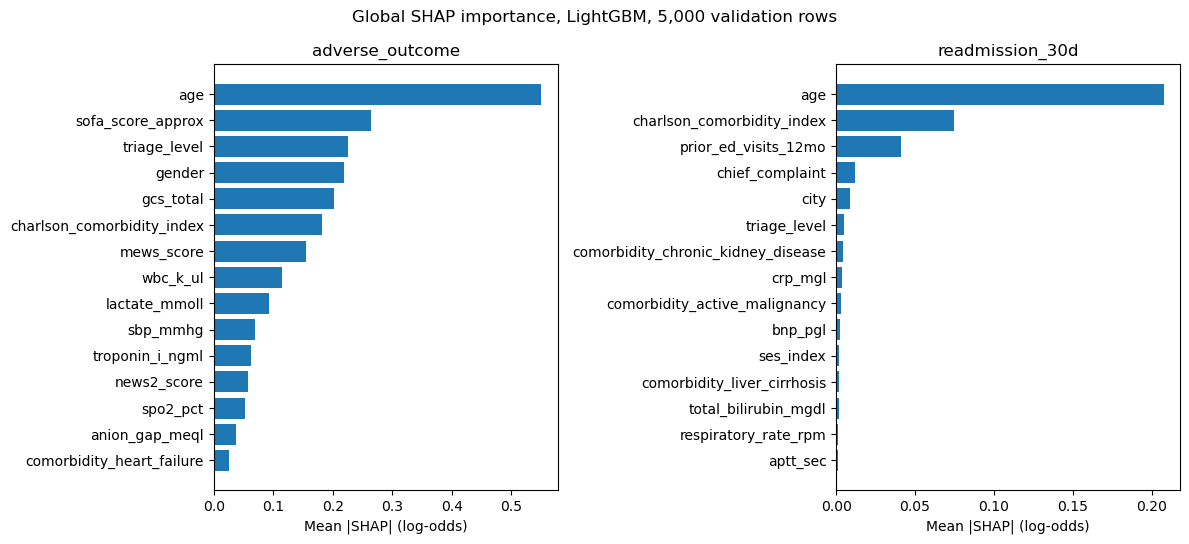

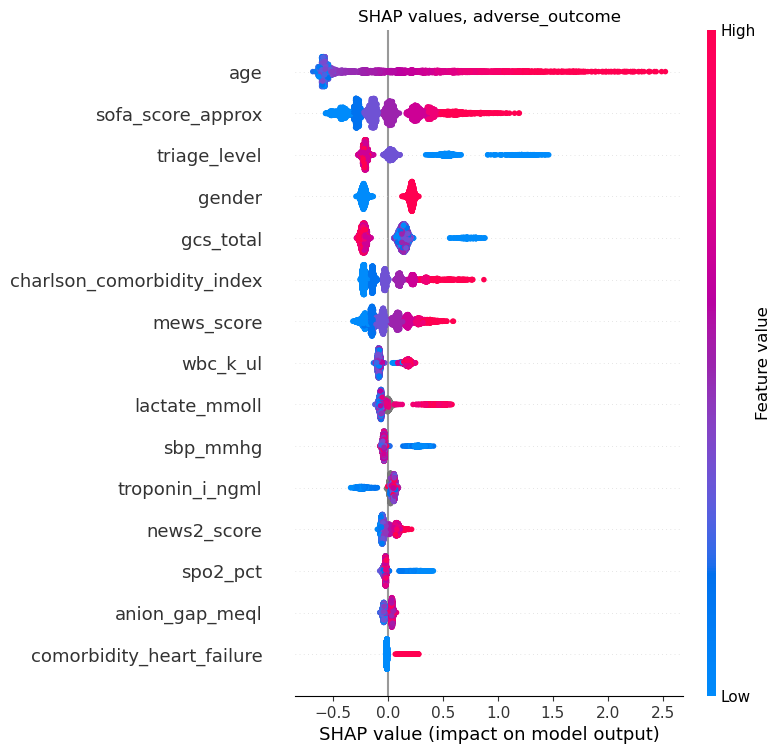

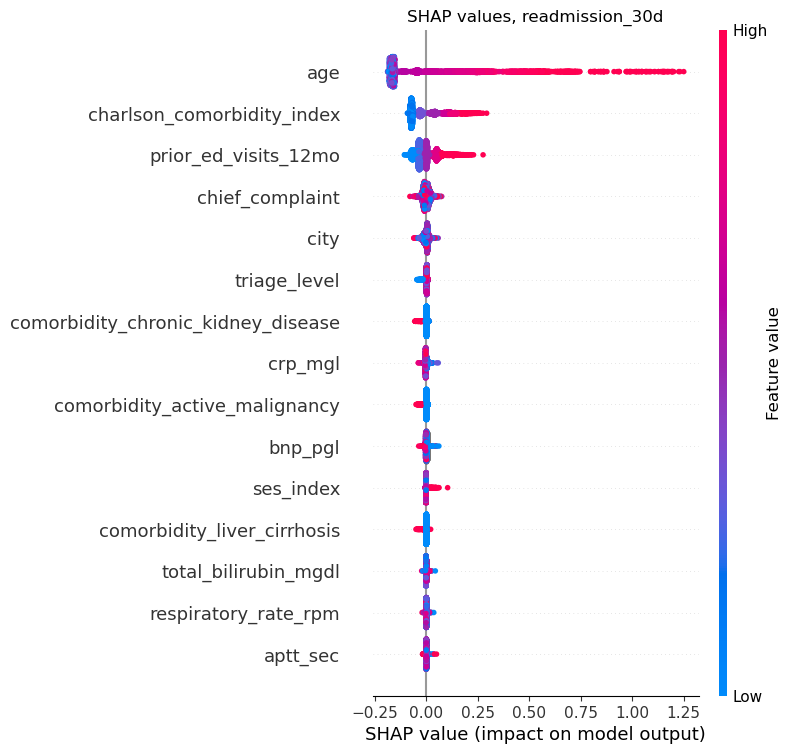

tables/shap_global_importance.csv | KB: 9.4
figures/shap_summary.png | KB: 119.5
figures/shap_beeswarm_adverse_outcome.png | KB: 149.4
figures/shap_beeswarm_readmission_30d.png | KB: 135.4


In [4]:
import matplotlib.pyplot as plt
import shap

shap_n = 5000
samp = val.sample(shap_n, random_state=42)
X_s = to_cat(samp)
X_plot = X_s.copy()
for c in cat_features:
    X_plot[c] = X_plot[c].cat.codes          # numeric codes, only used to colour the beeswarm

grp = feat_tbl.set_index("feature")["group"]
shap_vals, rows, grp_rows = {}, [], []

for t in targets:
    expl = shap.TreeExplainer(models[t])
    sv = expl.shap_values(X_s)
    if isinstance(sv, list):                 # older shap versions return one array per class
        sv = sv[1]
    sv = np.asarray(sv)
    base = float(np.ravel(expl.expected_value)[-1])
    raw = models[t].predict(X_s, raw_score=True)
    err = float(np.abs(sv.sum(axis=1) + base - raw).max())
    shap_vals[t] = sv

    imp = pd.Series(np.abs(sv).mean(axis=0), index=features).sort_values(ascending=False)
    print(t, "| rows explained:", sv.shape[0], "| features:", sv.shape[1],
          "| max additivity error:", round(err, 6))
    print("top 5 share of total mean |SHAP|:", round(imp.head(5).sum() / imp.sum(), 3),
          "| top 15 share:", round(imp.head(15).sum() / imp.sum(), 3))
    print(imp.head(15).round(4).to_string())
    g = imp.groupby(grp).sum().sort_values(ascending=False)
    print("share of total mean |SHAP| by group:")
    print((g / g.sum()).round(3).to_string())
    print()
    for f, v in imp.items():
        rows.append({"target": t, "feature": f, "group": grp[f], "mean_abs_shap": v})

pd.DataFrame(rows).round(5).to_csv(tables / "shap_global_importance.csv", index=False)

# ---- figure 1: top 15 bars, both targets ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, t in zip(axes, targets):
    imp = pd.Series(np.abs(shap_vals[t]).mean(axis=0), index=features).sort_values(ascending=False).head(15)
    ax.barh(imp.index[::-1], imp.values[::-1])
    ax.set_title(t)
    ax.set_xlabel("Mean |SHAP| (log-odds)")
fig.suptitle(f"Global SHAP importance, LightGBM, {shap_n:,} validation rows")
fig.tight_layout()
plt.savefig(figs / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- figure 2: beeswarm per target (direction of effect) ----
for t in targets:
    shap.summary_plot(shap_vals[t], X_plot, max_display=15, show=False)
    plt.title(f"SHAP values, {t}")
    plt.savefig(figs / f"shap_beeswarm_{t}.png", dpi=150, bbox_inches="tight")
    plt.show()

for f in ["tables/shap_global_importance.csv", "figures/shap_summary.png",
          "figures/shap_beeswarm_adverse_outcome.png", "figures/shap_beeswarm_readmission_30d.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [5]:
from scipy.stats import chi2_contingency

d = dev.copy()
d["age_band"] = pd.cut(d["age"], bins=[0, 40, 60, 80, 121], right=False,
                       labels=["0-39", "40-59", "60-79", "80+"])

print("adverse_outcome rate by gender (dev):")
print(d.groupby("gender")["adverse_outcome"].agg(["mean", "count"]).round(4))
ct = pd.crosstab(d["gender"], d["adverse_outcome"])
chi2 = chi2_contingency(ct)[0]
print("Cramer V, gender vs adverse_outcome:", round(float((chi2 / ct.values.sum()) ** 0.5), 4))
print()
print("rate by age band and gender (dev):")
print(d.groupby(["age_band", "gender"], observed=True)["adverse_outcome"].mean().unstack().round(4))
print()
gi = features.index("gender")
print("mean SHAP of gender by value (val sample, log-odds):")
print(pd.Series(shap_vals["adverse_outcome"][:, gi]).groupby(samp["gender"].values).agg(["mean", "count"]).round(4))
print()

for f in ["tables/shap_global_importance.csv", "figures/shap_summary.png",
          "figures/shap_beeswarm_adverse_outcome.png", "figures/shap_beeswarm_readmission_30d.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

adverse_outcome rate by gender (dev):
          mean   count
gender                
Female  0.3671  195760
Male    0.4496  204605
Cramer V, gender vs adverse_outcome: 0.0839

rate by age band and gender (dev):
gender    Female    Male
age_band                
0-39      0.2357  0.3096
40-59     0.3202  0.4055
60-79     0.5202  0.6129
80+       0.7373  0.8113

mean SHAP of gender by value (val sample, log-odds):
          mean  count
Female -0.2239   2437
Male    0.2124   2563

tables/shap_global_importance.csv | KB: 9.4
figures/shap_summary.png | KB: 119.5
figures/shap_beeswarm_adverse_outcome.png | KB: 149.4
figures/shap_beeswarm_readmission_30d.png | KB: 135.4


adverse_outcome | true positive | row 20420 | score 0.991 | outcome 1 | base score 0.392
   age +1.26; sofa_score_approx +0.85; triage_level +0.85; gcs_total +0.55; mews_score +0.48; sbp_mmhg +0.27; charlson_comorbidity_index +0.18; news2_score +0.17
adverse_outcome | false positive | row 25989 | score 0.968 | outcome 0 | base score 0.392
   age +1.01; sofa_score_approx +0.76; gcs_total +0.70; triage_level +0.54; mews_score +0.45; sbp_mmhg +0.28; charlson_comorbidity_index +0.19; gender -0.17
adverse_outcome | false negative | row 5531 | score 0.040 | outcome 1 | base score 0.392
   age -0.58; sofa_score_approx -0.47; mews_score -0.25; gcs_total -0.24; charlson_comorbidity_index -0.23; triage_level -0.23; gender -0.21; troponin_i_ngml -0.20
adverse_outcome | low risk | row 54538 | score 0.033 | outcome 0 | base score 0.392
   age -0.58; sofa_score_approx -0.49; mews_score -0.28; gcs_total -0.25; triage_level -0.23; charlson_comorbidity_index -0.23; gender -0.20; troponin_i_ngml -0.18


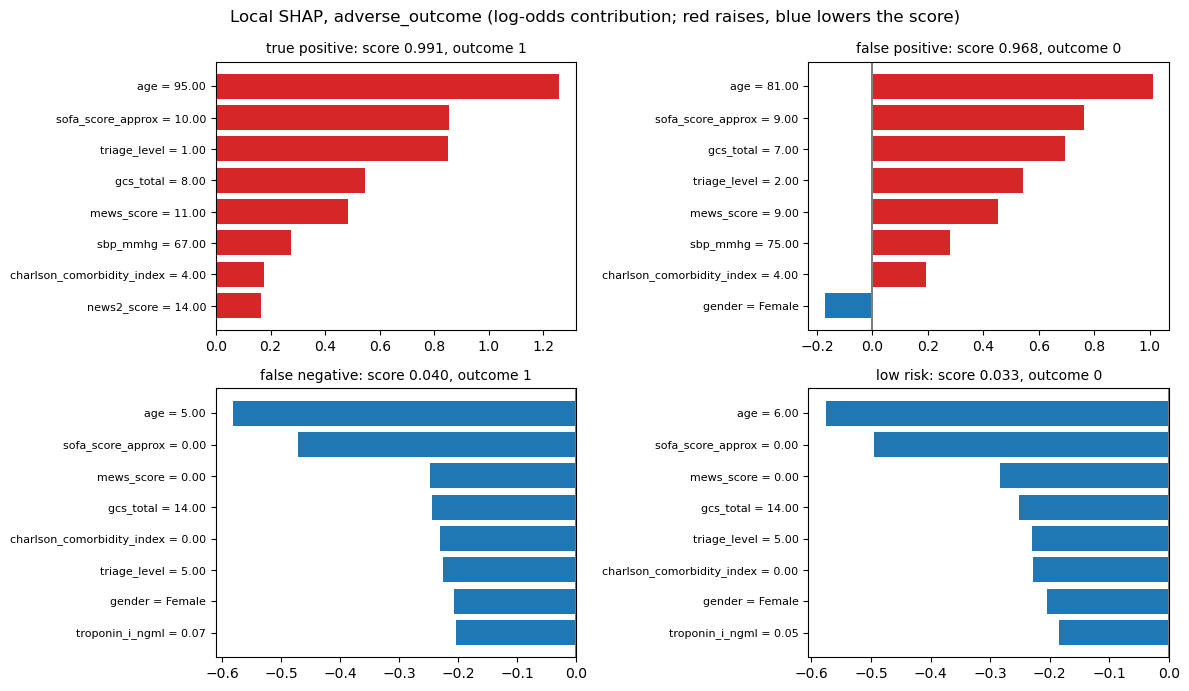


readmission_30d | true positive | row 16489 | score 0.448 | outcome 1 | base score 0.132
   age +1.18; charlson_comorbidity_index +0.27; prior_ed_visits_12mo +0.09; chief_complaint +0.05; lactate_mmoll +0.02; glucose_mgdl +0.02; city +0.02; egfr_ml_min +0.02
readmission_30d | false positive | row 61988 | score 0.429 | outcome 0 | base score 0.132
   age +1.15; prior_ed_visits_12mo +0.13; charlson_comorbidity_index +0.12; calcium_mgdl +0.05; lactate_mmoll +0.05; albumin_gdl +0.02; chief_complaint +0.02; sbp_mmhg +0.02
readmission_30d | false negative | row 21160 | score 0.095 | outcome 1 | base score 0.132
   age -0.17; charlson_comorbidity_index -0.07; prior_ed_visits_12mo -0.07; chief_complaint -0.03; city -0.02; triage_level -0.01; bnp_pgl -0.01; ast_ul -0.00
readmission_30d | low risk | row 34472 | score 0.094 | outcome 0 | base score 0.132
   age -0.17; charlson_comorbidity_index -0.07; prior_ed_visits_12mo -0.07; city -0.02; chief_complaint -0.02; triage_level -0.01; bnp_pgl -0.0

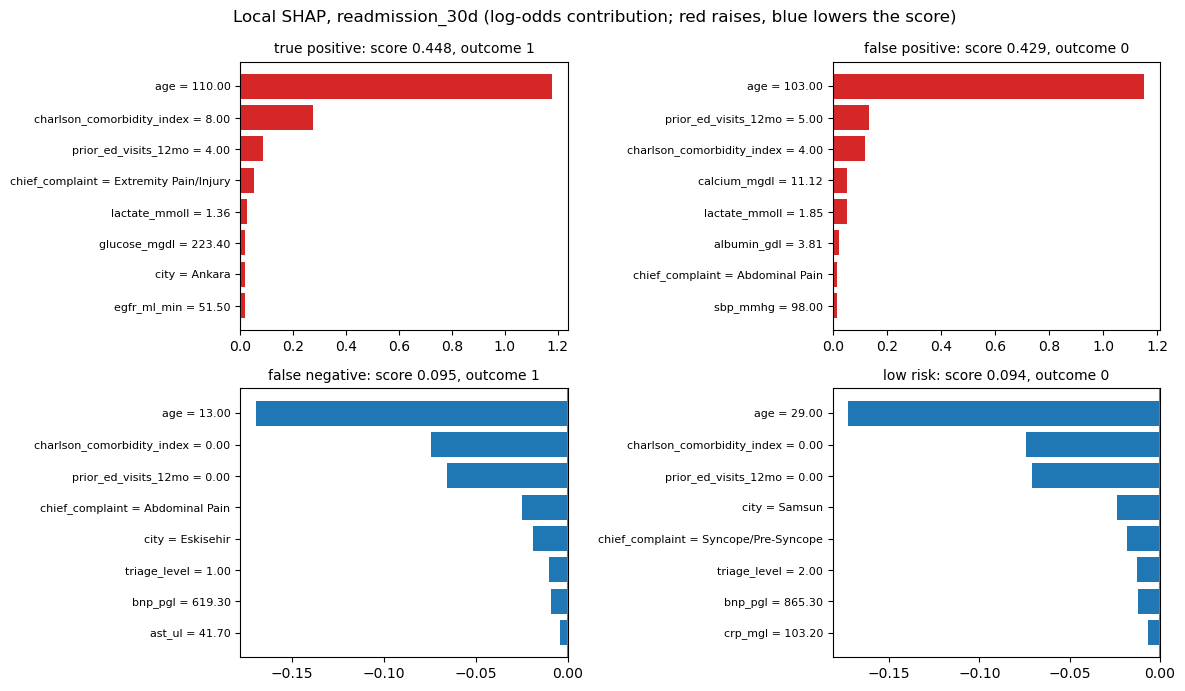


tables/shap_local_examples.csv | KB: 1.8
figures/shap_local_adverse_outcome.png | KB: 124.0
figures/shap_local_readmission_30d.png | KB: 136.7


In [6]:
eval_idx = np.where(~fit_mask)[0]
local_rows = []

for t in targets:
    s_e = p_val[t][eval_idx]
    y_e = val[t].values[eval_idx]
    pick = {
        "true positive":  eval_idx[np.where(y_e == 1)[0][np.argmax(s_e[y_e == 1])]],
        "false positive": eval_idx[np.where(y_e == 0)[0][np.argmax(s_e[y_e == 0])]],
        "false negative": eval_idx[np.where(y_e == 1)[0][np.argmin(s_e[y_e == 1])]],
        "low risk":       eval_idx[np.where(y_e == 0)[0][np.argmin(s_e[y_e == 0])]],
    }
    rows_idx = list(pick.values())
    Xl = to_cat(val.iloc[rows_idx])
    expl = shap.TreeExplainer(models[t])
    sv = expl.shap_values(Xl)
    if isinstance(sv, list):
        sv = sv[1]
    sv = np.asarray(sv)
    base = float(np.ravel(expl.expected_value)[-1])

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, (label, i), k in zip(axes.ravel(), pick.items(), range(4)):
        contrib = pd.Series(sv[k], index=features)
        top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
        shown = []
        for f, v in top.items():
            val_f = val.iloc[i][f]
            shown.append(f"{f} = {val_f:.2f}" if isinstance(val_f, (int, float, np.integer, np.floating)) else f"{f} = {val_f}")
        ax.barh(shown[::-1], top.values[::-1], color=["tab:red" if v > 0 else "tab:blue" for v in top.values[::-1]])
        ax.axvline(0, color="grey")
        ax.set_title(f"{label}: score {p_val[t][i]:.3f}, outcome {int(val[t].values[i])}", fontsize=10)
        ax.tick_params(axis="y", labelsize=8)
        print(f"{t} | {label} | row {i} | score {p_val[t][i]:.3f} | outcome {int(val[t].values[i])}"
              f" | base score {1/(1+np.exp(-base)):.3f}")
        print("   " + "; ".join(f"{f} {v:+.2f}" for f, v in top.items()))
        local_rows.append({"target": t, "case": label, "val_row": int(i), "encounter_id": val.iloc[i]["encounter_id"],
                           "score": float(p_val[t][i]), "outcome": int(val[t].values[i]),
                           "top_contributions": "; ".join(f"{f} {v:+.2f}" for f, v in top.items())})
    fig.suptitle(f"Local SHAP, {t} (log-odds contribution; red raises, blue lowers the score)")
    fig.tight_layout()
    plt.savefig(figs / f"shap_local_{t}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print()

pd.DataFrame(local_rows).round(4).to_csv(tables / "shap_local_examples.csv", index=False)
for f in ["tables/shap_local_examples.csv", "figures/shap_local_adverse_outcome.png",
          "figures/shap_local_readmission_30d.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

## Setup
Train on dev (2019 to 2021). Calibrate and explain on val (2022). Holdout rows were filtered out at read time and never loaded. LightGBM refit on dev with the Notebook 04 settings and tree counts (291 for adverse_outcome, 51 for readmission_30d). Refit predictions match the saved Notebook 04 predictions exactly (max difference 0.0, val PR-AUC 0.7553 and 0.2138).

## Calibration (reports/tables/calibration_metrics.csv, figures/calibration_curve.png)
Design fixed before any result: val split at the median arrival time. Calibrators fitted on the first half (66,919 rows, 2022-01-01 to 2022-07-02 17:00), scored on the second half (66,934 rows, 2022-07-02 18:00 to 2022-12-31 23:00). Selection rule: lowest Brier on the second half, and "none" is kept unless the gain is at least 0.0005.

| Target | Method | Brier | ECE | PR-AUC | Distinct scores |
|---|---|---:|---:|---:|---:|
| adverse_outcome | none | 0.17371 | 0.0055 | 0.7563 | 66,934 |
| | Platt | 0.17372 | 0.0054 | 0.7563 | 66,934 |
| | isotonic | 0.17372 | 0.0029 | 0.7506 | 205 |
| readmission_30d | none | 0.11366 | 0.0061 | 0.2101 | 64,916 |
| | Platt | 0.11365 | 0.0037 | 0.2101 | 64,916 |
| | isotonic | 0.11368 | 0.0039 | 0.2044 | 83 |

- Brier differences against "none" are at most 0.00002, and every paired bootstrap interval includes zero (for example Platt on readmission_30d: -0.00002, interval -0.00007 to 0.00004).
- Chosen calibrator: none, for both targets. The unweighted LightGBM already had ECE of 0.0055 and 0.0061.
- Isotonic lowers ECE but collapses the scores to 205 and 83 distinct values, and PR-AUC falls by about 0.0057 for both targets (no interval computed).
- ECE uses 10 equal-width bins. For readmission_30d nearly all scores sit in the first two bins, so Brier is the better comparison. The reliability figure uses deciles of predicted risk.
- These PR-AUC values come from the second half of val, so they differ from the full-val values in Notebook 04.
- Ranking after calibration is unchanged, since no calibrator was applied. The LightGBM rows of reports/tables/ranking_capacity_results.csv apply.

## Global SHAP (reports/tables/shap_global_importance.csv, figures/shap_summary.png, shap_beeswarm_*.png)
5,000 val rows (random sample, seed 42), TreeExplainer on the LightGBM models. Additivity check: max error 0.0 for both targets. Importance is mean |SHAP| in log-odds.

- adverse_outcome: age 0.550, sofa_score_approx 0.265, triage_level 0.226, gender 0.218, gcs_total 0.201, charlson_comorbidity_index 0.182, mews_score 0.156, wbc_k_ul 0.114, lactate_mmoll 0.092, sbp_mmhg 0.070. The top 5 carry 56.8% of total importance, the top 15 carry 89.8%.
- readmission_30d: age 0.208, charlson_comorbidity_index 0.074, prior_ed_visits_12mo 0.041, chief_complaint 0.012, city 0.009. The top 5 carry 85.5%, the top 15 carry 92.0%.
- Importance share by group, adverse_outcome: demographic 30.8%, laboratory 24.8%, vitals 23.2%, presentation 9.6%, comorbidity 9.4%, temporal 0.9%, institutional 0.7%, history 0.6%, medication 0.1%. The laboratory group includes sofa_score_approx, about 10% of total importance on its own.
- Importance share by group, readmission_30d: demographic 52.5%, comorbidity 21.9%, history 10.4%, laboratory 7.1%, presentation 4.3%, institutional 2.5%, vitals 1.3%, medication 0.1%, temporal 0.0%.
- Laboratory columns carry about a quarter of SHAP importance for adverse_outcome, while removing them cost 0.006 to 0.008 PR-AUC (Notebook 03). SHAP splits credit among correlated inputs (vitals, MEWS, NEWS2, SOFA), so the two numbers answer different questions. For readmission_30d the 7.1% laboratory share agrees with the null ablation.
- chief_complaint and city rank 4th and 5th for readmission_30d at 0.012 and 0.009, close to the noise floor of the Notebook 02 univariate scan. High-cardinality categoricals can fit noise. Not tested.

## Gender and adverse_outcome (dev rows)
- adverse_outcome rate: female 0.3671 (195,760 rows), male 0.4496 (204,605 rows). Cramer's V 0.084.
- The gap holds in every age band: 7.4 points (0 to 39), 8.5 (40 to 59), 9.3 (60 to 79), 7.4 (80+).
- Mean SHAP: female -0.224, male +0.212 log-odds.
- The Notebook 02 scan missed gender because it printed only the top 12 per target and a V of 0.084 fell below the cut. This is an association in generated data. Model performance by gender is checked in Notebook 08.

## Local SHAP examples (reports/tables/shap_local_examples.csv, figures/shap_local_*.png)
Selection rule, fixed before the cell ran, on the second half of val: the highest-scoring row with outcome 1 (true positive), the highest-scoring row with outcome 0 (false positive), the lowest-scoring row with outcome 1 (false negative) and the lowest-scoring row with outcome 0 (low risk). These are extremes by construction, not typical cases.

- adverse_outcome: the true positive (score 0.991) and false positive (0.968) share the same leading contributions (age +1.26 vs +1.01, sofa_score_approx +0.85 vs +0.76, triage_level +0.85 vs +0.54, gcs_total +0.55 vs +0.70, mews_score +0.48 vs +0.45). The false negative (0.040) and low-risk row (0.033) are also close to identical (age -0.58 in both, sofa_score_approx -0.47 vs -0.49, mews_score -0.25 vs -0.28).
- readmission_30d: scores in the second half of val range from 0.094 (low-risk row) to 0.448 (true positive), so no encounter received a probability above 45%. The true positive (0.448) and false positive (0.429) differ little (age +1.18 vs +1.15), as do the false negative (0.095) and low-risk row (0.094).
- In each pair the model saw nearly the same evidence and the outcome differed. This is consistent with an outcome component the 90 features do not explain. Not tested. Notebook 08 compares errors with correct predictions.
- Contributions describe model behaviour, not causes or clinical necessity.

## Limitations
- The calibration halves are chronological halves of one year. Calibration drift across years was not tested.
- The tree counts came from early stopping on val, so val scores are slightly optimistic.
- The SHAP sample is 5,000 rows. The stability of ranks among close values (sofa_score_approx, triage_level, gender, gcs_total) was not tested.
- SHAP splits credit among correlated features. Group shares are not causal.
- Local examples are extremes chosen by rule.

## Moves to Notebook 08
- Reuse the LightGBM refit (same parameters and tree counts). The chosen calibrator is "none", so nothing is fitted for holdout in Notebook 09.
- Per-year performance for 2019 to 2021 is in-sample for a model fitted on dev. Settle the design for temporal analysis at the start of Notebook 08, before computing anything. Holdout rows stay unloaded.
- Subgroups: gender (8-point gap in adverse_outcome rate), age band, hospital type, region, urban/rural, season and day/night.
- Error analysis compares false negatives and false positives with correct predictions, including the pairs seen in the local examples.